# Pythonで学ぶ画像認識　第6章 画像キャプショニング
## 第6.5節 Transformerによる画像キャプショニングを実装してみよう

### ライブラリの準備

###モジュールのインポートとGoogleドライブのマウント

In [3]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import datetime
from typing import Sequence, Dict, Tuple, Union
from tqdm import tqdm
import pickle
import random
from torch.utils.data.sampler import SubsetRandomSampler
from PIL import Image
import skimage.transform
from collections import deque

import torch
from torch import nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence
from torchvision import models
import torchvision.transforms as T
import torchvision.datasets as dataset

from timm.scheduler import CosineLRScheduler

import sqlite3

from pydlshogi2.dataloader import HcpeDataLoader
import cshogi
from cshogi.dlshogi import make_input_features, FEATURES1_NUM, FEATURES2_NUM

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from dlshogi.network.policy_value_network import policy_value_network
from dlshogi import serializers
from dlshogi.common import MAX_MOVE_LABEL_NUM
class CNNEncoder(nn.Module):
    '''
    Show and tellのエンコーダ
    dim_embedding: 埋め込み次元
    '''
    def __init__(self, dim_embedding: int, arg_network: str, arg_model: str):
        super().__init__()

        # dlshogiのpolicy networkとvalue networkの出力層前までのネットワークをバックボーンネットワークとする
        model = policy_value_network(arg_network)
        serializers.load_npz(arg_model, model)
        self.backbone = model

        # デコーダへの出力
        self.linear = nn.Linear(2*MAX_MOVE_LABEL_NUM*9*9, dim_embedding)

    '''
    エンコーダの順伝播
    features1: 入力1, [バッチサイズ, チャネル数(62), 高さ(9), 幅(9)]
    features2: 入力2, [バッチサイズ, チャネル数(57), 高さ(9), 幅(9)]
    '''
    def forward(self, features1: torch.Tensor, features2: torch.Tensor):
        # 特徴抽出 -> [バッチサイズ, 2*27(MAX_MOVE_LABEL)*9*9]
        # 今回はバックボーンネットワークは学習させない
        with torch.no_grad():
            policy, value, policy_features, value_features, resnet_features = self.backbone(features1, features2)
            policy_features = torch.flatten(policy_features, 1)
            value_features = torch.flatten(value_features, 1)
            features = torch.cat([policy_features, value_features], dim=-1)

        # 全結合
        features = self.linear(features)

        return features

### 位置エンコーディングの実装

In [5]:
class PositionalEncoding(nn.Module):
    '''
    位置エンコーディング （Positional encoding）
    dim_embedding: 埋込み次元
    dropout      : ドロップアウト確率
    max_len      : 入力の最大系列長
    temperature  : 温度定数
    '''
    def __init__(self, dim_embedding: int, dropout: float=0.1,
                 max_len: int=5000, temperature=10000):
        super().__init__()

        assert dim_embedding % 2 == 0

        self.dropout = nn.Dropout(p=dropout)

        dim_t = torch.arange(0, dim_embedding, 2)
        dim_t = dim_t / dim_embedding
        dim_t = temperature ** dim_t

        x_encoding = torch.arange(max_len).unsqueeze(1)
        x_encoding = x_encoding / dim_t

        # 位置情報を保持するテンソル
        pe = torch.zeros(max_len, dim_embedding)
        pe[:, ::2] = x_encoding.sin()
        pe[:, 1::2] = x_encoding.cos()

        # PEをメモリに保存
        self.register_buffer('pe', pe)

    '''
    位置エンコーディングの順伝播
    x: 位置エンコーディングを埋め込む対象のテンソル,
       [バッチサイズ, 系列長, 埋め込み次元]
    '''
    def forward(self, x: torch.Tensor):
        seq = x.shape[1]
        x = x + self.pe[:seq]
        x = self.dropout(x)

        return x

### Transformerデコーダの実装

In [6]:
class TransformerDecoderLayer(nn.Module):
    '''
    Transformerデコーダ層
    dim_hidden     : 特徴量次元
    num_heads      : アテンションヘッドの数
    dim_feedforward: FNNの中間特徴量次元
    dropout        : ドロップアウト確率
    '''
    def __init__(self, dim_hidden: int, num_heads: int,
                 dim_feedforward: int=2048, dropout: int=0.1):
        super().__init__()

        # 単語ベクトルに対するマルチヘッド自己アテンション
        self.self_attention = nn.MultiheadAttention(
            dim_hidden, num_heads, dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(dim_hidden)
        self.dropout1 = nn.Dropout(dropout)

        # エンコーダとデコーダ中間出力に対するマルチヘッドアテンション
        self.cross_attention = nn.MultiheadAttention(
            dim_hidden, num_heads, dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim_hidden)
        self.dropout2 = nn.Dropout(dropout)

        # FNN＆レイヤー正規化
        self.fnn = nn.Sequential(
            nn.Linear(dim_hidden, dim_feedforward),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, dim_hidden)
        )
        self.norm3 = nn.LayerNorm(dim_hidden)
        self.dropout3 = nn.Dropout(dropout)

    '''
    Transformerデコーダ層の順伝播
    tgt     : デコーダへの入力系列,
              [バッチサイズ, 系列長, 埋め込み次元]
    memory  : エンコーダ層の特徴量, [バッチサイズ, 1, 埋め込み次元]
    tgt_mask: 入力系列のマスク, [系列長, 系列長]
    '''
    def forward(self, tgt: torch.Tensor, memory: torch.Tensor,
                tgt_mask: torch.Tensor=None):

        # デコーダ入力に対するマスク付きマルチヘッド自己アテンション
        tgt2 = self.self_attention(
            query=tgt, key=tgt, value=tgt, attn_mask=tgt_mask)[0]
        tgt = tgt + self.dropout1(tgt2)  # 残差接続
        tgt = self.norm1(tgt)            # レイヤー正規化

        # エンコーダとデコーダ中間出力に対するマルチヘッド交差アテンション
        tgt2 = self.cross_attention(
            query=tgt, key=memory, value=memory)[0]
        tgt = tgt + self.dropout2(tgt2)  # 残差接続
        tgt = self.norm2(tgt)            # レイヤー正規化

        # FNN&レイヤー正規化
        tgt2 = self.fnn(tgt)
        tgt = tgt + self.dropout3(tgt2)  # 残差接続
        tgt = self.norm3(tgt)            # レイヤー正規化

        return tgt

### CaptioningTransformerの実装

In [7]:
class CaptioningTransformer(nn.Module):
    '''
    CaptioningTransformerのコンストラクタ
    dim_embedding  : 埋め込み次元
    dim_feedforward: FNNの中間特徴次元
    num_heads      : マルチヘッドアテンションのヘッド数
    num_layers     : Transformerデコーダ層の数
    vocab_size     : 辞書の次元
    null_index     : NULLのID
    dropout        : ドロップアウト確率
    '''
    def __init__(self, dim_embedding: int, dim_feedforward: int,
                 num_heads: int, num_layers: int, vocab_size: int,
                 null_index: int, dropout: float=0.5):
        super().__init__()

        # 単語埋め込み
        self.embed = nn.Embedding(
            vocab_size, dim_embedding, padding_idx=null_index)

        # 位置エンコーディング
        self.positional_encoding = PositionalEncoding(dim_embedding)

        # Transformerデコーダ
        self.decoder_layers = nn.ModuleList([
            TransformerDecoderLayer(
                dim_embedding, num_heads, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])

        # 単語出力分布計算
        self.linear = nn.Linear(dim_embedding, vocab_size)

        # パラメータ初期化
        self._reset_parameters()

    '''
    パラメータの初期化関数
    '''
    def _reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
            elif isinstance(module, nn.LayerNorm):
                nn.init.zeros_(module.bias)
                nn.init.ones_(module.weight)

    ''' CaptioningTransformerの順伝播処理
    features: 画像特徴量 [バッチサイズ, 埋め込み次元]
    captions: 正解キャプション [バッチサイズ, 系列長]
    '''
    def forward(self, features: torch.Tensor,
                captions: torch.Tensor):
        seq = captions.shape[1]

        # 単語埋め込み [バッチサイズ, 系列長]
        # -> [バッチサイズ, 系列長, 埋め込み次元]
        embeddings = self.embed(captions)

        # 位置エンコーディング
        embeddings = self.positional_encoding(embeddings)

        features = features.unsqueeze(1)

        # 未来のキャプションを参照しないようにマスク行列を生成
        tgt_mask = torch.tril(features.new_ones((seq, seq)))
        tgt_mask = tgt_mask == 0

        # Transformerデコーダでキャプション生成
        # 画像の特徴も入力する
        for layer in self.decoder_layers:
            embeddings = layer(embeddings, features, tgt_mask)

        # [バッチサイズ, 系列長, 埋め込み次元]
        # -> [バッチサイズ, 系列長, 辞書の次元]
        preds = self.linear(embeddings)

        return preds

    '''
    CaptioningTransformerのサンプリング処理
    features  : 画像特徴ベクトル [バッチサイズ, 埋め込み次元]
    word_to_id: 単語->単語ID辞書
    max_length: 最大キャプション長
    '''
    import torch
    import torch.nn.functional as F

    @torch.no_grad()
    def sample(self, features: torch.Tensor, word_to_id: dict, max_length: int=512, k: int=None, p: float=None):
        bs = features.shape[0]
        captions = features.new_full((bs, 1), word_to_id['<start>'], dtype=torch.int64)

        for _ in range(max_length):
            preds = self.forward(features, captions)
            preds = preds[:, -1]  # 最後の単語の確率分布

            # Softmaxで確率分布に変換
            probs = F.softmax(preds, dim=1)

            # **Top-k サンプリング**
            if k is not None:
                topk_values, topk_indices = torch.topk(probs, k, dim=1)
                probs = topk_values
                indices = topk_indices
            else:
                indices = torch.arange(probs.shape[1], device=probs.device).expand_as(probs)

            # **Top-p サンプリング**
            if p is not None:
                sorted_probs, sorted_indices = torch.sort(probs, descending=True, dim=1)
                cumulative_probs = torch.cumsum(sorted_probs, dim=1)

                # p を超える最初のインデックスを探す
                keep_mask = cumulative_probs <= p
                keep_mask[:, 0] = True  # 少なくとも1つは選択されるように

                # フィルタリング
                probs = sorted_probs * keep_mask
                probs /= probs.sum(dim=1, keepdim=True)  # 正規化
                indices = sorted_indices

            # サンプリング
            sampled_idx = torch.multinomial(probs, 1)
            words = indices.gather(1, sampled_idx)

            captions = torch.cat((captions, words), dim=1)

        return captions

In [8]:
'''
batch     : features1, features2, move_label, result, コメントインデックスをまとめたもの
word_to_id: 単語->単語ID辞書
'''
def collate_func(x1, x2, move_label, result, index, word_to_id: Dict[str, int], db_path):

    # SQLiteデータベースに接続
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    # index のすべての要素に対して一度に SQL クエリを実行
    index_values = [idx.item() for idx in index]
    placeholders = ', '.join(['?'] * len(index_values))  # SQLクエリ用のプレースホルダ
    cursor.execute(f'SELECT * FROM comments WHERE comment_index IN ({placeholders})', tuple(index_values))
    rows = cursor.fetchall()

    # 取得したデータを使ってトークナイズ
    captions = []
    for row in rows:
        caption = row[1]  # キャプションが row[1] にあると仮定
        captions.append(tokenize_caption(caption, word_to_id))

    # 接続を閉じる
    conn.close()
    
    # キャプションの長さが降順になるように並び替え
    batch = zip(x1, x2, move_label, result, captions)
    batch = sorted(batch, key=lambda x: len(x[4]), reverse=True)
    x1, x2, move_label, result, captions = zip(*batch)
    x1 = torch.stack(x1)
    x2 = torch.stack(x2)
    move_label = torch.stack(move_label)
    result = torch.stack(result)

    lengths = [cap.shape[0] for cap in captions]
    targets = torch.full((len(captions), max(lengths)), 
                         word_to_id['<null>'], dtype=torch.int64)
    for i, cap in enumerate(captions):
        end = lengths[i]
        targets[i, :end] = cap[:end]
    
    return x1, x2, move_label, result, targets, lengths

In [9]:
from utils.token_move_tool import words_with_shogi_move
'''
トークナイザ - 文章(caption)を単語IDのリスト(tokens_id)に変換
caption   : 画像キャプション
word_to_id: 単語->単語ID辞書
'''
def tokenize_caption(caption: str, word_to_id: Dict[str, int]):
    tokens = words_with_shogi_move(caption)
    
    tokens_temp = []    
    # 単語についたピリオド、カンマを削除
    for token in tokens:
        if token in {'。', '、', '.', ',', '！', '？', '!', '?'}: 
            continue
        
        tokens_temp.append(token)
    
    tokens = tokens_temp        
        
    # 文章(caption)を単語IDのリスト(tokens_id)に変換
    tokens_ext = ['<start>'] + tokens + ['<end>']
    tokens_id = []
    for k in tokens_ext:
        if k in word_to_id:
            tokens_id.append(word_to_id[k])
        else:
            tokens_id.append(word_to_id['<unk>'])
    
    return torch.Tensor(tokens_id)

###学習におけるハイパーパラメータやオプションの設定

In [ ]:
class ConfigTrain(object):
    '''
    ハイパーパラメータ、システム共通変数の設定
    '''
    def __init__(self):

        # ハイパーパラメータ
        self.dim_embedding = 300   # 埋め込み層の次元
        self.dim_feedforward = 128 # FNNの中間特徴量次元
        self.num_heads = 4         # マルチヘッドアテンションのヘッド数
        self.num_layers = 8        # Transformerデコーダ層の層数
        self.lr = 0.001            # 学習率
        self.dropout = 0.3         # dropout確率
        self.batch_size = 32       # ミニバッチ数
        self.num_epochs = 100       # エポック数→Colab無料版でテストする際は10未満に修正を推奨

        # パスの設定
        self.train_data = "/workspace/train_AtoR.hcpe"
        self.test_data = "/workspace/test_AtoR.hcpe"
        self.dlshogi_model_path = "/workspace/model/model_resnet10_swish-072_for_caption"
        self.dlshogi_network = "kifcaption"

        self.comment_file = "/workspace/kif_caption/comments_AtoR.db"
        self.word_to_id_file = '/workspace/kif_caption/word_to_id_AtoR.pkl'
        self.save_directory = '/workspace/kif_caption/model'

        # 検証に使う学習セット内のデータの割合
        self.val_ratio = 0.3

        # データローダーに使うCPUプロセスの数
        self.num_workers = 4

        # 学習に使うデバイス
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # 移動平均で計算する損失の値の数
        self.moving_avg = 100

### 学習率スケジューラ

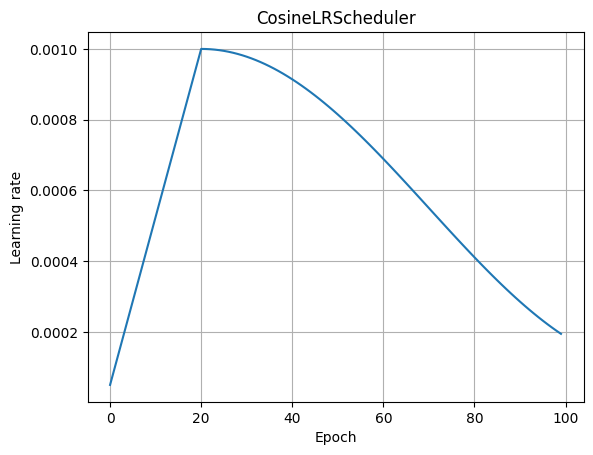

In [9]:
linear = torch.nn.Linear(1, 1)
optimizer = torch.optim.AdamW(linear.parameters())
scheduler = CosineLRScheduler(
    optimizer, t_initial=100, lr_min=1e-4, warmup_t=20,
    warmup_lr_init=5e-5, warmup_prefix=True)

lrs = []
for i in range(100):
    lrs.append(scheduler._get_lr(i))
plt.plot(lrs)
plt.title("CosineLRScheduler")
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.grid()

### 学習を行う関数

In [ ]:
def train():
    config = ConfigTrain()

    # 辞書（単語→単語ID）の読み込み
    with open(config.word_to_id_file, 'rb') as f:
        word_to_id = pickle.load(f)

    # 辞書サイズを保存
    vocab_size = len(word_to_id)
        
    # モデル出力用のディレクトリを作成
    os.makedirs(config.save_directory, exist_ok=True)

    # train dataloader
    train_dataloader = HcpeDataLoader(config.train_data, config.batch_size, config.device, shuffle=True)

    # test data loader
    test_dataloader = HcpeDataLoader(config.test_data, config.batch_size, config.device)

    # モデルの定義
    encoder = CNNEncoder(config.dim_embedding, config.dlshogi_network, config.dlshogi_model_path)
    decoder = CaptioningTransformer(
        config.dim_embedding, config.dim_feedforward,
        config.num_heads, config.num_layers, vocab_size,
        word_to_id['<null>'], config.dropout)
    encoder.to(config.device)
    decoder.to(config.device)

    # 損失関数の定義
    loss_func = lambda x, y: F.cross_entropy(
        x, y, ignore_index=word_to_id.get('<null>', None))

    # 最適化手法の定義
    params = list(decoder.parameters()) + \
    list(encoder.linear.parameters())
    optimizer = torch.optim.AdamW(params, lr=config.lr)

    # WarmupとCosine Decayを行うスケジューラを利用
    scheduler = CosineLRScheduler(
        optimizer, t_initial=config.num_epochs, lr_min=1e-4,
        warmup_t=20, warmup_lr_init=5e-5, warmup_prefix=True)

    # 学習経過の書き込み
    now = datetime.datetime.now()
    train_loss_file = '{}/6-5_train_loss_{}.csv'\
        .format(config.save_directory, now.strftime('%Y%m%d_%H%M%S'))
    val_loss_file = '{}/6-5_val_loss_{}.csv'\
        .format(config.save_directory, now.strftime('%Y%m%d_%H%M%S'))
    
    total_train_samples = len(train_dataloader)
    total_train_step = total_train_samples // config.batch_size

    total_test_samples = len(test_dataloader)
    total_test_step = total_test_samples // config.batch_size

    # 学習
    val_loss_best = float('inf')
    for epoch in range(config.num_epochs):
        with tqdm(train_dataloader, total=total_train_step) as pbar:
            pbar.set_description(f'[エポック {epoch + 1}]')

            # 学習モードに設定
            encoder.train()
            decoder.train()

            train_losses = deque()
            for x1, x2, move_label, result, index in pbar:
                x1, x2, move_label, result, captions, lengths = collate_func(x1, x2, move_label, result, index, word_to_id, config.comment_file)
                # ミニバッチを設定
                captions = captions.to(config.device)

                optimizer.zero_grad()

                # エンコーダ-デコーダモデル
                features = encoder(x1, x2)
                # 最後の単語から次を予測する必要はないため最後の単語を除外
                captions_in = captions[:, :-1]
                outputs = decoder(features, captions_in)

                # 損失の計算
                # <start>の予測は行わないため除外
                targets = captions[:, 1:]
                # 単語軸が第1軸である必要があるため、転置
                outputs = outputs.transpose(1, 2)
                loss = loss_func(outputs, targets)

                # 誤差逆伝播
                loss.backward()

                optimizer.step()

                # 学習時の損失をログに書き込み
                train_losses.append(loss.item())
                if len(train_losses) > config.moving_avg:
                    train_losses.popleft()
                pbar.set_postfix({
                    'loss': torch.Tensor(train_losses).mean().item()})
                with open(train_loss_file, 'a') as f:
                    print(f'{epoch}, {loss.item()}', file=f)

        # 学習率を表示
        print(f'学習率: {scheduler._get_lr(epoch)}')

        # 検証
        with tqdm(test_dataloader, total=total_test_step) as pbar:
            pbar.set_description(f'[検証]')

            # 評価モード
            encoder.eval()
            decoder.eval()

            val_losses = []
            for x1, x2, move_label, result, index in pbar:
                x1, x2, move_label, result, captions, lengths = collate_func(x1, x2, move_label, result, index, word_to_id, config.comment_file)

                # ミニバッチを設定
                captions = captions.to(config.device)

                # エンコーダ-デコーダモデル
                features = encoder(x1, x2)
                # 最後の単語から次を予測する必要はないため最後の単語を除外
                captions_in = captions[:, :-1]
                outputs = decoder(features, captions_in)

                # 損失の計算
                # <start>の予測は行わないため除外
                targets = captions[:, 1:]
                # 単語軸が第1軸である必要があるため、転置
                outputs = outputs.transpose(1, 2)
                loss = loss_func(outputs, targets)
                val_losses.append(loss.item())

                # Validation Lossをログに書き込み
                with open(val_loss_file, 'a') as f:
                    print(f'{epoch}, {loss.item()}', file=f)

        # Loss 表示
        val_loss = np.mean(val_losses)
        print(f'Validation loss: {val_loss}')

        # より良い検証結果が得られた場合、モデルを保存
        if val_loss < val_loss_best:
            val_loss_best = val_loss

            # エンコーダモデルを保存
            torch.save(
                encoder.state_dict(),
                f'{config.save_directory}/transformer_encoder_best.pth')

            # デコーダモデルを保存
            torch.save(
                decoder.state_dict(),
                f'{config.save_directory}/transformer_decoder_best.pth')

###学習データの解凍

###学習の実行

In [11]:
train()

[エポック 1]: 100%|██████████| 18598/18598 [25:09<00:00, 12.32it/s, loss=4.12]


AttributeError: 'CosineLRScheduler' object has no attribute 'get_epoch_values'

###デモにおけるハイパーパラメータやオプションの設定

In [10]:
class ConfigDemo(object):
    '''
    ハイパーパラメータ、システム共通変数の設定
    '''
    def __init__(self):

        # ハイパーパラメータ
        self.dim_embedding = 300   # 埋め込み層の次元
        self.dim_feedforward = 128 # FNNの中間特徴量次元
        self.num_heads = 4         # マルチヘッドアテンションのヘッド数
        self.num_layers = 8        # Transformerデコーダ層の層数

        # パスの設定
        # 画像キャプショニング推論
        # self.img_dirirectory = 'drive/MyDrive/python_image_recognition/data/image_captioning/'
        self.word_to_id_file = '/workspace/kif_caption/word_to_id_AtoR.pkl'

        self.dlshogi_model_path = "/workspace/model/model_resnet10_swish-072_for_caption"
        self.dlshogi_network = "kifcaption"

        self.comment_file = "/workspace/kif_caption/comments_AtoR.db"
        self.id_to_word_file = '/workspace/kif_caption/id_to_word_AtoR.pkl'
        self.save_directory = '/workspace/kif_caption/model'

        # 推論に使うデバイス
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

###デモを行う関数

In [11]:
from IPython.display import display, SVG
def demo(sfen):
    config = ConfigDemo()

    # 辞書（単語→単語ID）の読み込み
    with open(config.word_to_id_file, 'rb') as f:
        word_to_id = pickle.load(f)

    # 辞書（単語ID→単語）の読み込み
    with open(config.id_to_word_file, 'rb') as f:
        id_to_word = pickle.load(f)

    # 辞書サイズを保存
    vocab_size = len(id_to_word)

    # エンコーダモデルの定義
    encoder = CNNEncoder(config.dim_embedding, config.dlshogi_network, config.dlshogi_model_path)
    encoder.to(config.device)
    encoder.eval()

    # デコーダモデルの定義
    decoder = CaptioningTransformer(
        config.dim_embedding, config.dim_feedforward,
        config.num_heads, config.num_layers, vocab_size,
        word_to_id['<null>'])
    decoder.to(config.device)
    decoder.eval()

    # モデルの学習済み重みパラメータをロード
    encoder.load_state_dict(
        torch.load(f'{config.save_directory}/transformer_encoder_best.pth'))
    decoder.load_state_dict(
        torch.load(f'{config.save_directory}/transformer_decoder_best.pth'))


    # 画像読み込み
    board = cshogi.Board(sfen)
    features1 = np.zeros((1, FEATURES1_NUM, 9, 9), dtype=np.float32)
    features2 = np.zeros((1, FEATURES2_NUM, 9, 9), dtype=np.float32)
    make_input_features(board, features1, features2)

    x1 = torch.tensor(features1, device=config.device)
    x2 = torch.tensor(features2, device=config.device)

    # エンコーダ・デコーダモデルによる予測
    feature = encoder(x1, x2)
    sampled_ids = decoder.sample(feature, word_to_id)

    # 入力画像を表示
    display(SVG(board.to_svg()))

    # 画像キャプショニングの実行
    sampled_caption = []
    for word_id in sampled_ids[0]:
        word = id_to_word[word_id.item()]
        sampled_caption.append(word)
        if word == '<end>':
            break

    sentence = ' '.join(sampled_caption)
    print(f'出力キャプション: {sentence}')


###デモの実行

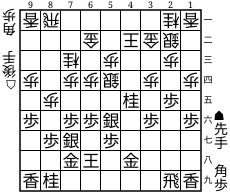

出力キャプション: <start> 玉 から 離れる が 大丈夫 だろう か <end>


In [23]:
demo("lr5nl/3g1kgs1/2n1p2p1/p1pps1p1p/1p3N1P1/P1PPS1P1P/1PS1P4/2GK1G3/LN5RL b BPbp 43")

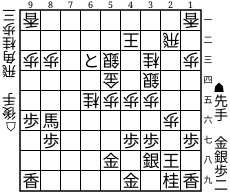

出力キャプション: <start> 歩 を 取ら ず に 馬 を 引い て 辛抱 し た 桂 を 助ける の は 難しい よう だ が △4八銀打 が 非常 に 厳しい <end>


In [22]:
demo("l7l/5k1r1/pp1+Ps1n1p/4g1s2/3nppp2/P+B5p1/1P3PP1P/4G1SK1/L4G1NL b GS2Prbn3p 83")

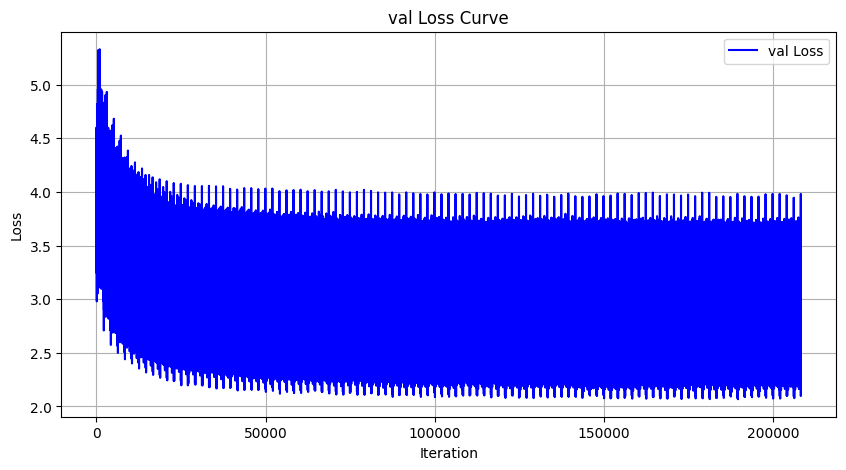

In [80]:
import matplotlib.pyplot as plt
import pandas as pd

# CSVファイルのパスを指定
csv_file = "/workspace/kif_caption/model/6-5_val_loss_20250307_150648.csv"

# CSVファイルを読み込む
df = pd.read_csv(csv_file, header=None, names=["epoch", "loss"])

# 学習曲線をプロット
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["loss"], label="val Loss", color="b")

# グラフの設定
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("val Loss Curve")
plt.legend()
plt.grid()

# グラフを表示
plt.show()

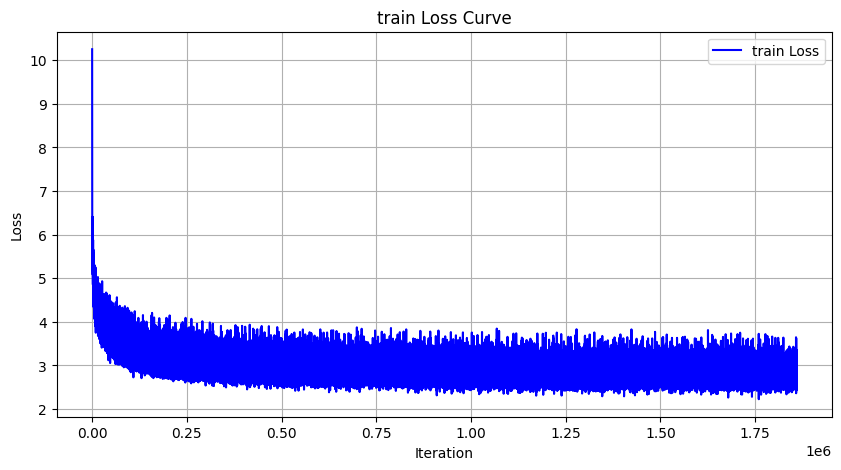

In [81]:
import matplotlib.pyplot as plt
import pandas as pd

# CSVファイルのパスを指定
csv_file = "/workspace/kif_caption/model/6-5_train_loss_20250307_150648.csv"

# CSVファイルを読み込む
df = pd.read_csv(csv_file, header=None, names=["epoch", "loss"])

# 学習曲線をプロット
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["loss"], label="train Loss", color="b")

# グラフの設定
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("train Loss Curve")
plt.legend()
plt.grid()

# グラフを表示
plt.show()